# MNIST Digit Classification


## Step 1: Import Libraries and Load Data


In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load MNIST training and test datasets


In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define transformations for the images
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert images to PyTorch tensors
    transforms.Normalize((0.1307,), (0.3081,))  # Normalize with MNIST mean and std
])

# Load the training dataset
train_dataset = datasets.MNIST(
    root='./data',  # Where to store the dataset
    train=True,     # This is training data
    download=True,  # Download if not present
    transform=transform  # Apply transformations
)

# Load the test dataset
test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Create data loaders for batch processing
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

Using device: cpu


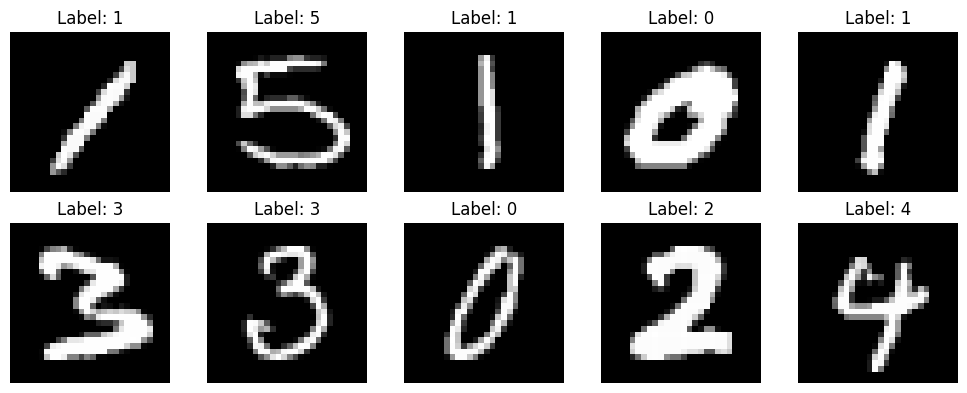

In [16]:
# Function to display images
def show_images(images, labels):
    fig, axes = plt.subplots(2, 5, figsize=(10, 4))
    axes = axes.flatten()

    for i in range(10):
        axes[i].imshow(images[i].reshape(28, 28), cmap='gray')
        axes[i].set_title(f"Label: {labels[i]}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Get some random training images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Show images
show_images(images[:10], labels[:10])

## Step 2: Create a Simple Fully Connected Neural Network


In [50]:
class FCN0(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 12),
            nn.ReLU(),
            nn.Linear(12, 10)
        )

    def forward(self, x):
        return self.net(x)


# FCN Variant 1
class FCN1(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )
        
    def forward(self, x):
        return self.net(x)

# FCN Variant 2
class FCN2(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )
        
    def forward(self, x):
        return self.net(x)

# FCN Variant 3
class FCN3(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )
        
    def forward(self, x):
        return self.net(x)
model0 = FCN0()
model1 =  FCN1()
model2 = FCN2()
model3 = FCN3()

In [52]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

results = [
    ("FCN-0", count_params(model0)),
    ("FCN-1", count_params(model1)),
    ("FCN-2", count_params(model2)),
    ("FCN-3", count_params(model3)),
]

for name, params in results:
    print(f"{name}: Params = {params}")


FCN-0: Params = 9550
FCN-1: Params = 50890
FCN-2: Params = 109386
FCN-3: Params = 242762


## Step 3: Training & Evaluating the Neural Network : FCN1, FCN2, FCN3

In [53]:
def train_and_evaluate(model, model_name, epochs=5):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        print(f"[{model_name}] Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(train_loader):.4f}")

    # Evaluation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"[{model_name}] Test Accuracy: {accuracy:.2f}%")
    return accuracy


In [64]:
acc0 = train_and_evaluate(model1, "FCN-0")
acc1 = train_and_evaluate(model1, "FCN-1")
acc2 = train_and_evaluate(model2, "FCN-2")
acc3 = train_and_evaluate(model3, "FCN-3")

[FCN-0] Epoch 1/5 - Loss: 0.2904
[FCN-0] Epoch 2/5 - Loss: 0.2136
[FCN-0] Epoch 3/5 - Loss: 0.1939
[FCN-0] Epoch 4/5 - Loss: 0.1759
[FCN-0] Epoch 5/5 - Loss: 0.1854
[FCN-0] Test Accuracy: 95.20%
[FCN-1] Epoch 1/5 - Loss: 0.1850
[FCN-1] Epoch 2/5 - Loss: 0.1692
[FCN-1] Epoch 3/5 - Loss: 0.1667
[FCN-1] Epoch 4/5 - Loss: 0.1597
[FCN-1] Epoch 5/5 - Loss: 0.1546
[FCN-1] Test Accuracy: 95.58%
[FCN-2] Epoch 1/5 - Loss: 0.2735
[FCN-2] Epoch 2/5 - Loss: 0.1873
[FCN-2] Epoch 3/5 - Loss: 0.1717
[FCN-2] Epoch 4/5 - Loss: 0.1517
[FCN-2] Epoch 5/5 - Loss: 0.1404
[FCN-2] Test Accuracy: 96.12%
[FCN-3] Epoch 1/5 - Loss: 0.3142
[FCN-3] Epoch 2/5 - Loss: 0.2059
[FCN-3] Epoch 3/5 - Loss: 0.1761
[FCN-3] Epoch 4/5 - Loss: 0.1567
[FCN-3] Epoch 5/5 - Loss: 0.1490
[FCN-3] Test Accuracy: 95.89%


## Step 5: Simple Convolutional Neural Network
- While our simple neural network works reasonably well, convolutional neural networks (CNNs) are typically better for image processing tasks:

In [62]:

class CNN0(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 10, kernel_size=3, stride=1, padding=1),  # 1→10
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 28→14

            nn.Conv2d(10, 16, kernel_size=3, stride=1, padding=1),  # 10→16
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 14→7

            nn.Flatten(),  # 16×7×7 = 784
            nn.Linear(784, 10)
        )

    def forward(self, x):
        return self.net(x)

class CNN1(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 10, kernel_size=3, stride=1, padding=1),  # 1→10
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 28→14

            nn.Conv2d(10, 24, kernel_size=3, stride=1, padding=1),  # 10→24
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 14→7

            nn.Flatten(),  # 24×7×7 = 1176
            nn.Linear(1176, 48),
            nn.ReLU(),
            nn.Linear(48, 10)
        )

    def forward(self, x):
        return self.net(x)

class CNN2(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),  # 1→16
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 28→14

            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),  # 16→32
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 14→7

            nn.Flatten(),  # 32×7×7 = 1568
            nn.Linear(1568, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )
        
    def forward(self, x):
        return self.net(x)

class CNN3(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 24, kernel_size=3, stride=1, padding=1),  # 1→24
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 28→14

            nn.Conv2d(24, 48, kernel_size=3, stride=1, padding=1),  # 24→48
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 14→7

            nn.Flatten(),  # 48×7×7 = 2352
            nn.Linear(2352, 96),
            nn.ReLU(),
            nn.Linear(96, 10)
        )
        
    def forward(self, x):
        return self.net(x)

cnn0 = CNN0()
cnn1 = CNN1()
cnn2 = CNN2()
cnn3 = CNN3()

In [63]:
cnn_results = [
    ("CNN-0", count_params(cnn0)),
    ("CNN-1", count_params(cnn1)),
    ("CNN-2", count_params(cnn2)),
    ("CNN-3", count_params(cnn3)),
]

for name, params in cnn_results:
    print(f"{name}: Params = {params}")

CNN-0: Params = 9406
CNN-1: Params = 59270
CNN-2: Params = 105866
CNN-3: Params = 237514


## Step 6: Training the Convolutional Neural Network : SimpleCNN

In [65]:
acc_cnn0 = train_and_evaluate(cnn0, "CNN-0")
acc_cnn1 = train_and_evaluate(cnn1, "CNN-1")
acc_cnn2 = train_and_evaluate(cnn2, "CNN-2")
acc_cnn3 = train_and_evaluate(cnn3, "CNN-3")

[CNN-0] Epoch 1/5 - Loss: 0.1264
[CNN-0] Epoch 2/5 - Loss: 0.0659
[CNN-0] Epoch 3/5 - Loss: 0.0580
[CNN-0] Epoch 4/5 - Loss: 0.0575
[CNN-0] Epoch 5/5 - Loss: 0.0524
[CNN-0] Test Accuracy: 97.88%
[CNN-1] Epoch 1/5 - Loss: 0.1385
[CNN-1] Epoch 2/5 - Loss: 0.0698
[CNN-1] Epoch 3/5 - Loss: 0.0618
[CNN-1] Epoch 4/5 - Loss: 0.0586
[CNN-1] Epoch 5/5 - Loss: 0.0554
[CNN-1] Test Accuracy: 98.21%
[CNN-2] Epoch 1/5 - Loss: 0.1951
[CNN-2] Epoch 2/5 - Loss: 0.0871
[CNN-2] Epoch 3/5 - Loss: 0.0766
[CNN-2] Epoch 4/5 - Loss: 0.0714
[CNN-2] Epoch 5/5 - Loss: 0.0679
[CNN-2] Test Accuracy: 98.01%
[CNN-3] Epoch 1/5 - Loss: 0.3185
[CNN-3] Epoch 2/5 - Loss: 0.1586
[CNN-3] Epoch 3/5 - Loss: 0.1366
[CNN-3] Epoch 4/5 - Loss: 0.1329
[CNN-3] Epoch 5/5 - Loss: 0.1236
[CNN-3] Test Accuracy: 96.63%


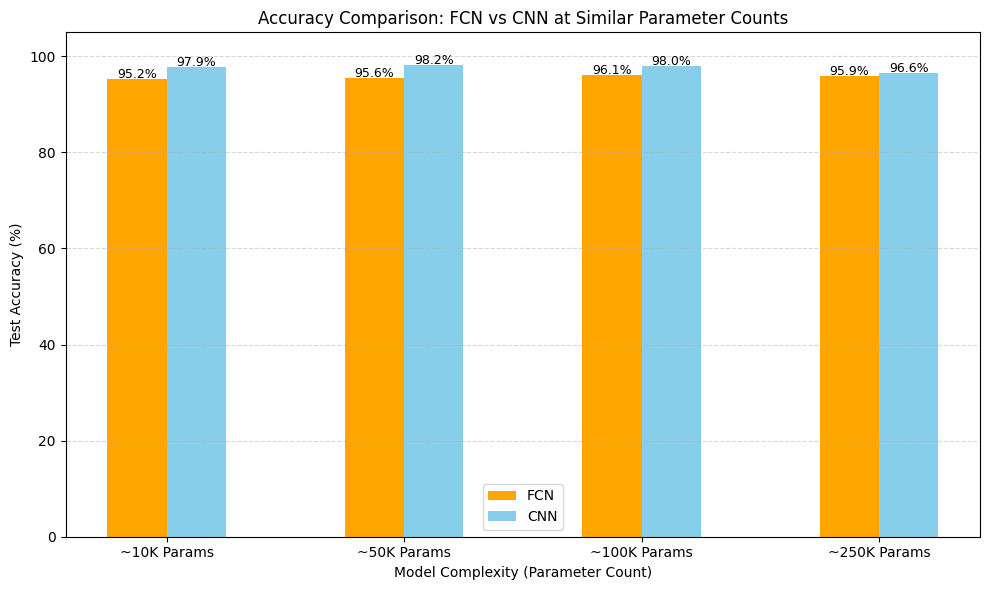

In [66]:
import matplotlib.pyplot as plt
import numpy as np

# Model groups
model_levels = ['~10K Params',  '~50K Params', '~100K Params', '~250K Params']

# Accuracy for FCN and CNN at each level — replace with actual values
fcn_acc = [acc0, acc1, acc2, acc3]
cnn_acc = [acc_cnn0, acc_cnn1, acc_cnn2, acc_cnn3]

x = np.arange(len(model_levels))  # Label locations
width = 0.25  # Width of bars

plt.figure(figsize=(10, 6))
bars1 = plt.bar(x - width/2, fcn_acc, width, label='FCN', color='orange')
bars2 = plt.bar(x + width/2, cnn_acc, width, label='CNN', color='skyblue')

# Add text labels above bars
for i in range(len(x)):
    plt.text(x[i] - width/2, fcn_acc[i] + 0.2, f"{fcn_acc[i]:.1f}%", ha='center', fontsize=9)
    plt.text(x[i] + width/2, cnn_acc[i] + 0.2, f"{cnn_acc[i]:.1f}%", ha='center', fontsize=9)

plt.xlabel('Model Complexity (Parameter Count)')
plt.ylabel('Test Accuracy (%)')
plt.title('Accuracy Comparison: FCN vs CNN at Similar Parameter Counts')
plt.xticks(x, model_levels)
plt.ylim(0, 105)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## References

- [PyTorch MNIST Tutorial](https://pythonguides.com/pytorch-mnist/)
- [MaxPool2D Explanation](https://www.geeksforgeeks.org/computer-vision/apply-a-2d-max-pooling-in-pytorch/)
- [PyTorch MaxPool2D Docs](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html)
